### Tool Trends

Trends of paper implementations grouped by framework: Comparison of  PyTorch vs. TensorFlow

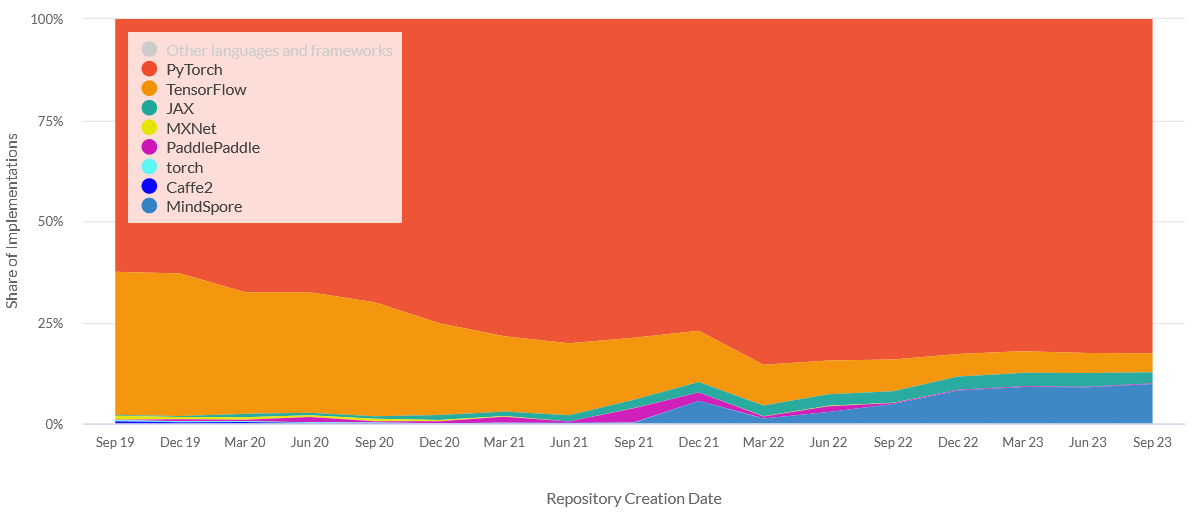

### PyTorch Intro

Pytorch - один из самых популярных фреймворков глубокого обучения для ML-специалистов. Фактически сегодня это еще и целая [экосистема](https://pytorch.org/ecosystem/) инструментов


В библиотеке есть четыре ключевых составляющих:

- Развитый инструментарий для работы с тензорами. Он похож на numpy, но даёт дополнительные возможности по контролю выделяемой памяти, что важно при работе с большими моделями и данными.
- Простое построение динамического вычислительного графа, позволяющего получать градиенты целевых функций от параметров модели.
- Большой набор готовых слоёв для построения нейронных сетей произвольной архитектуры.
- Возможность перенаправлять вычисления на графические процессоры GPU.



In [ ]:
import torch

#### Тензоры


Создание тензора

In [ ]:
x = torch.empty(5, 3)
print(x)

tensor([[2.1887e-35, 0.0000e+00, 1.3123e-33],
        [4.4013e-41, 8.9683e-44, 0.0000e+00],
        [1.1210e-43, 0.0000e+00, 1.3302e-40],
        [0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00]])


Случайная инициализация в диапазоне [0; 1]

In [ ]:
x = torch.rand(5, 3)
print(x)

tensor([[0.9705, 0.5475, 0.7896],
        [0.8881, 0.9037, 0.3273],
        [0.3882, 0.7410, 0.3636],
        [0.7341, 0.3908, 0.1609],
        [0.7035, 0.5767, 0.7229]])


Инициализация нулями

In [ ]:
x = torch.zeros(5, 3, dtype=torch.long)
print(x)

tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]])


Создание непосредственно из данных

In [ ]:
x = torch.tensor([5.5, 3])
print(x)

tensor([5.5000, 3.0000])


Из другого тензора

In [ ]:
x = x.new_ones(5, 3, dtype=torch.double)      # new_* methods take in sizes
print(x)

x = torch.randn_like(x, dtype=torch.float)    # the same size as input that is filled with random numbers from a normal distribution, override dtype!
print(x)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)
tensor([[ 1.7482, -0.2888, -1.1214],
        [-0.4371,  0.8603, -0.0270],
        [ 1.1441,  0.4255,  0.1994],
        [-0.5022,  0.9330,  0.7588],
        [-0.4192, -0.0896,  2.6611]])


При преобразовании типа (если он меняется) под данные выделяется новая память

In [ ]:
x = torch.Tensor(5, 3)
y = x.long()
y = x.float()

Размер тензора

In [ ]:
x.size()

torch.Size([5, 3])

In [ ]:
x.shape

torch.Size([5, 3])

NB! torch.Size - абстракция от tuple, поэтому поддерживаются те же операции, как и с кортежами

#### Операции с тензорами


In [ ]:
y = torch.rand(5, 3)
print(x + y)

tensor([[0.9345, 0.1184, 0.5150],
        [0.2502, 0.1045, 0.4600],
        [0.0599, 0.8489, 0.5579],
        [0.2305, 0.7613, 0.0268],
        [0.3066, 0.4026, 0.0751]])


In [ ]:
print(torch.add(x, y))

tensor([[0.9345, 0.1184, 0.5150],
        [0.2502, 0.1045, 0.4600],
        [0.0599, 0.8489, 0.5579],
        [0.2305, 0.7613, 0.0268],
        [0.3066, 0.4026, 0.0751]])


Выходная переменная как параметр

In [ ]:
result = torch.empty(5, 3)
torch.add(x, y, out=result)
print(result)

tensor([[0.9345, 0.1184, 0.5150],
        [0.2502, 0.1045, 0.4600],
        [0.0599, 0.8489, 0.5579],
        [0.2305, 0.7613, 0.0268],
        [0.3066, 0.4026, 0.0751]])


in-place операции - operation_ syntax, новая память не выделяется

In [ ]:
x.add(y)

tensor([[0.9345, 0.1184, 0.5150],
        [0.2502, 0.1045, 0.4600],
        [0.0599, 0.8489, 0.5579],
        [0.2305, 0.7613, 0.0268],
        [0.3066, 0.4026, 0.0751]])

In [ ]:
x.add_(y)

tensor([[0.9345, 0.1184, 0.5150],
        [0.2502, 0.1045, 0.4600],
        [0.0599, 0.8489, 0.5579],
        [0.2305, 0.7613, 0.0268],
        [0.3066, 0.4026, 0.0751]])

Синтаксический сахар NumPy индексации

In [ ]:
print(x[:, 1])

tensor([0.1184, 0.1045, 0.8489, 0.7613, 0.4026])


Форма тензора (число индексов и их размерности) меняется функциями `view` и `reshape`

In [ ]:
x = torch.randn(4, 4)
y = x.view(16)
z = x.view(-1, 8) # Одна из размерностей может быть равна -1 и тогда она будет посчитана автоматически
print(x.size(), y.size(), z.size())

torch.Size([4, 4]) torch.Size([16]) torch.Size([2, 8])


`view` - создает другое представление исходного тензора. При изменении формы `view` меняется `x.stride()`. Новый тензор всегда делит (share) данные с исходным тензором

`reshape` не дает гарантии на шэринг данных: сначала проверяется `is_contiguous` и если результа - False, вызывается `contiguous` (создаёт новую память). После этого вызывается `view`

In [ ]:
x = torch.randn(4, 4)
y = x.reshape(16)
z = x.reshape(-1, 8)
print(x.size(), y.size(), z.size())

torch.Size([4, 4]) torch.Size([16]) torch.Size([2, 8])


Получение значения тензора из одного элемента

In [ ]:
x = torch.randn(1)
print(x)
print(x.item())

tensor([-0.9616])
-0.9615567922592163


In [ ]:
y[1].item()

-0.02647615596652031

Проверка доступности GPU и создание тензора на GPU

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")          # a CUDA device object
    y = torch.ones_like(x, device=device)  # directly create a tensor on GPU
    x = x.to(device)                       # or just use strings ``.to("cuda")``
    z = x + y
    print(z)
    print(z.to("cpu", torch.double))

tensor([0.0384], device='cuda:0')
tensor([0.0384], dtype=torch.float64)


Чтобы не прописывать device руками

In [ ]:
if torch.cuda.is_available():
  device = "cuda:0"
else:
  device = "cpu"
device

'cuda:0'

Выигрыш во времени от использования GPU

In [ ]:
%%time

x1 = torch.eye(10000)
y1 = torch.eye(10000)
z1 = x1.mm(y1)

CPU times: user 15.7 s, sys: 592 ms, total: 16.3 s
Wall time: 16.3 s


In [ ]:
%%time

x1 = torch.eye(10000, device=device)
y1 = torch.eye(10000, device=device)
z1 = x1.mm(y1)

CPU times: user 509 µs, sys: 27 ms, total: 27.6 ms
Wall time: 27.4 ms


#### Autograd - automatic differentiation engine

[PyTorch 101, Part 1: Understanding Graphs, Automatic Differentiation and Autograd](https://blog.paperspace.com/pytorch-101-understanding-graphs-and-automatic-differentiation/)

В центре большинства современных приемов машинного обучения лежит расчет градиентов. Это в особенности касается нейронных сетей, где для обновления весовых коэффициентов используется алгоритм обратного распространения

Autograd предоставляет классы и функции, реализующие автоматическое дифференцирование произвольных скалярных функций. Это требует минимальных изменений в существующем коде - нужно только объявить Tensor, для которого должны вычисляться градиенты, с атрибутом `requires_grad=True`

In [ ]:
x = torch.ones(2, 2, requires_grad=True)
print(x)

tensor([[1., 1.],
        [1., 1.]], requires_grad=True)


In [ ]:
x.grad == None

True

In [ ]:
x.grad_fn == None

True

После применения какой-либо операции к тензору атрибуту `grad_fn`  присваивается объект `Function`, который добавляется в граф вычислений для обратного распространения градиента.



In [ ]:
y = x + 2
print(y)

tensor([[3., 3.],
        [3., 3.]], grad_fn=<AddBackward0>)


In [ ]:
z = y * y * 3
out = z.mean()

print(z, out)

tensor([[27., 27.],
        [27., 27.]], grad_fn=<MulBackward0>) tensor(27., grad_fn=<MeanBackward0>)


`.grad_fn` может меняться "на лету"

In [ ]:
a = torch.randn(2, 2)
a = ((a * 3) / (a - 1))
print(a.requires_grad)
a.requires_grad_(True)
print(a.requires_grad)
b = (a * a).sum()
print(b.grad_fn)

False
True


Метод `backward` корневого узла графа вычислений запускает процедуру вычисления градиентов в листовых (is_leaf) узлах, имеющих атрибут requires_grad. Граф дифференцируется по цепочке (chain rule)

In [ ]:
out.backward()

In [ ]:
print(x.grad)

tensor([[4.5000, 4.5000],
        [4.5000, 4.5000]])


По умолчанию промежуточные (не листовые) узлы графа не хранят прошедшие через них градиентов.

In [ ]:
print(y.grad)

None


<ipython-input-168-b81046718426>:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  print(y.grad)


Эту ситуацию можно изменить, вызвав для для конкретного узла метод retain_grad

In [ ]:
x = torch.ones(2, 2, requires_grad=True)
y = x + 2
y.retain_grad()
z = y * y * 3
out = z.mean()
out.backward()

In [ ]:
print(x.grad)

tensor([[4.5000, 4.5000],
        [4.5000, 4.5000]])


In [ ]:
print(y.grad)

tensor([[4.5000, 4.5000],
        [4.5000, 4.5000]])


Иногда с листовыми узлами необходимо проделать действия, не меняя при этом графа. Такие действия проводят, используя контекстный менедежр `no_grad`, которое блокирует создание новых узлов графа

In [ ]:
print(x.requires_grad)
print((x ** 2).requires_grad)

with torch.no_grad(): # потом можно включить вручную torch.enable_grad()
    print((x ** 2).requires_grad)

True
True
False


[inference mode](https://pytorch.org/docs/stable/generated/torch.inference_mode.html)




Inference mode is the **extreme version of no-grad** mode. Just like in no-grad mode, computations in inference mode are not recorded in the backward graph, but enabling inference mode will **allow PyTorch to speed up your model** even more. This better runtime comes with a drawback: **tensors created in inference mode will not be able to be used in computations to be recorded by autograd after exiting inference mode.**




При помощи метода `detach` можно получит "отсоединенный" от графа тензор, который будет ссылаться на данные исходного узла, но не быть частью графа

In [ ]:
print(x.requires_grad)
y = x.detach()
print(y.requires_grad)

True
False


Еще про автоматическое дифференцирование в PyTorch:

[Особенности автоматического дифференцирования в PyTorch. Часть 1](https://habr.com/ru/companies/barsgroup/articles/719196/)

[Особенности автоматического дифференцирования в PyTorch. Часть 2](https://habr.com/ru/companies/barsgroup/articles/720676/)

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('Electrical_Grid_Stability.csv', sep=';')
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stability
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,1
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0


In [ ]:
X, y = df.drop('stability', axis=1), df['stability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(8000, 12)

In [ ]:
model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1307
           1       0.74      0.72      0.73       693

    accuracy                           0.82      2000
   macro avg       0.80      0.79      0.80      2000
weighted avg       0.82      0.82      0.82      2000



### PyTorch Logistic Regression

In [ ]:
import os
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm.notebook import tqdm


> Полностью воспроизводимые результаты не гарантируются в релизах PyTorch, отдельных коммитах или на разных платформах. Более того, результаты могут не воспроизводиться между выполнениями на CPU и GPU, даже при использовании идентичных начальных значений.





In [ ]:
def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # When running on the CuDNN backend, two further options must be set
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set as {seed}")

set_seed(42)

Random seed set as 42


In [ ]:
class LogisticRegressionTorch(nn.Module):
    def __init__(self, num_labels, input_size):
        super(LogisticRegressionTorch, self).__init__()
        self.linear = nn.Linear(input_size, num_labels) # https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/linear.py#L50

    def forward(self, x):
        y_pred = torch.sigmoid(self.linear(x))
        return y_pred

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
def train_model(model):
  loss_function = nn.BCELoss()
  optimizer = optim.SGD(model.parameters(), lr=0.1)

  for epoch in tqdm(range(100)):
      model.zero_grad()
      log_probs = model(X_train_tensor.to(device))
      loss = loss_function(log_probs, y_train_tensor)
      loss.backward()
      optimizer.step()
  return model

In [ ]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1).to(device)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(device)

In [ ]:
model = LogisticRegressionTorch(num_labels=1, input_size=12)
model.to(device)

LogisticRegressionTorch(
  (linear): Linear(in_features=12, out_features=1, bias=True)
)

In [ ]:
model = train_model(model)

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
with torch.no_grad():
  log_probs = model(X_test_tensor)
  y_pred = (log_probs >= 0.5).int().cpu()

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.98      0.80      1307
           1       0.71      0.11      0.19       693

    accuracy                           0.68      2000
   macro avg       0.69      0.54      0.50      2000
weighted avg       0.69      0.68      0.59      2000



Не впечатляет... Видимо, стоит попробовать усложнить модель. Давайте сделаем ее многослойной

### Многослойная модель

In [ ]:
class LogisticRegressionTorch_v2(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size):
        super(LogisticRegressionTorch_v2, self).__init__()
        self.linear_1 = nn.Linear(input_size, hidden_size)
        self.linear_2 = nn.Linear(hidden_size, num_labels)

    def forward(self, x):
        x = self.linear_1(x)
        x = torch.relu(x)
        x = self.linear_2(x)
        y_pred = torch.sigmoid(x)
        return y_pred

In [ ]:
model = LogisticRegressionTorch_v2(num_labels=1, input_size=12, hidden_size=12)
model.to(device)

LogisticRegressionTorch_v2(
  (linear_1): Linear(in_features=12, out_features=12, bias=True)
  (linear_2): Linear(in_features=12, out_features=1, bias=True)
)

In [ ]:
model = train_model(model)

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
with torch.no_grad():
  log_probs = model(X_test_tensor)
  y_pred = (log_probs >= 0.5).int().cpu()

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.91      0.83      1307
           1       0.73      0.45      0.56       693

    accuracy                           0.75      2000
   macro avg       0.75      0.68      0.69      2000
weighted avg       0.75      0.75      0.73      2000

